In [25]:
%load_ext autoreload
%autoreload 2

import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from astropy.io import fits
import csv

from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import astropy.constants as const
from astropy.coordinates import SkyCoord
from astropy.table import Table, unique, join

cosmo = FlatLambdaCDM(H0=70*u.km / (u.Mpc*u.s), Om0=0.286, Ob0=0.047)

# funky plot packages
from astropy.convolution import convolve, Gaussian2DKernel, Tophat2DKernel
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import SymLogNorm
from matplotlib.cm import get_cmap

os.chdir('/home/finneas/Documents/COMAP/stacking/')

import lim_stacker as st

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# set up params

In [26]:
params = st.parameters()
params.savepath = 'hx_s12_241203'
params.rotseed = 22222
params.xwidth = 3
params.ywidth = 3
params.freqwidth = 7
params.plotcubelet = True
params.physicalspace = False
params.rotate = False
params.beamwidth = params.beamwidth / 2
params.chanwidth = 0.03125 / 2
params.gauss_kernel = Gaussian2DKernel(params.beamwidth)

# load in a spectrum to test on

this is using a cubelet object (ie the output from a single stack run), but you could use any combo of frequency values and measured luminosities

In [27]:
# path to stack output
os.chdir('/home/finneas/Documents/COMAP/for_finneas/241214_fiuducial_sim_13587_noise11110_x3f3')

In [28]:
cube = st.cubelet('data', params)

In [29]:
DATA_FILE = '/home/finneas/Documents/COMAP/for_finneas/results_wlowz.pkl'

with open(DATA_FILE, 'rb') as f:
    data = pickle.load(f)

In [30]:
uspecvals = data['linelum'] / data['dlinelum'] # spectrum values (these are S/N values)
ufreqvals = data['centfreq'] # frequency values corresponding to the spectrum values

In [31]:
sorted_data = sorted(zip(uspecvals, ufreqvals), key=lambda item: item[1])

# Unzip the sorted data back into separate lists
specvals, freqvals = zip(*sorted_data)

## plot up to test

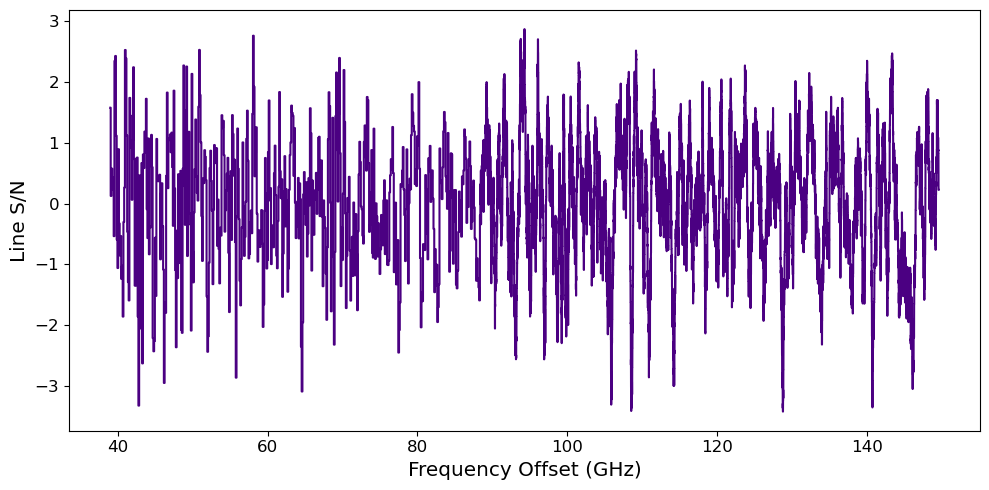

In [32]:
#%matplotlib notebook

fig,ax = plt.subplots(1, figsize=(10,5), tight_layout=True)

ax.step(freqvals, specvals, where='mid', color='indigo')
ax.set_xlabel('Frequency Offset (GHz)', fontsize='x-large')
ax.set_ylabel(r"Line S/N", fontsize='x-large')
#ax.set_xlim(90,92)
ax.tick_params(labelsize='large')

plt.show()

# define a spectrum kernel

this is the shape you expect your signal to be in -- here it's just a gaussian with FWHM of ~ 596 km/s (fit to simulations gives this value)

## unit conversions from km/s to GHz to pix

In [33]:
fwhm = 596
std = fwhm / (2*np.sqrt(2*np.log(2))) # gaussian standard deviation from full width at half maximum

In [34]:
std_ghz = (std*u.km/u.s / const.c * 30*u.GHz).to(u.GHz) # step size in ghz

In [35]:
std_ghz

<Quantity 0.02532731 GHz>

In [36]:
# signal width in units of channels (the actual spacing of the data points)
chanspacing = np.diff(freqvals)[0] * u.GHz # the spacing of the data points
std_chan = std_ghz / chanspacing
std_chan

<Quantity 0.25327311>

## load in convolution kernel functions

In [37]:
from astropy.convolution import convolve, Gaussian1DKernel

## define kernel

In [38]:
kernel = Gaussian1DKernel(std_chan)

## plot it (just as a test)

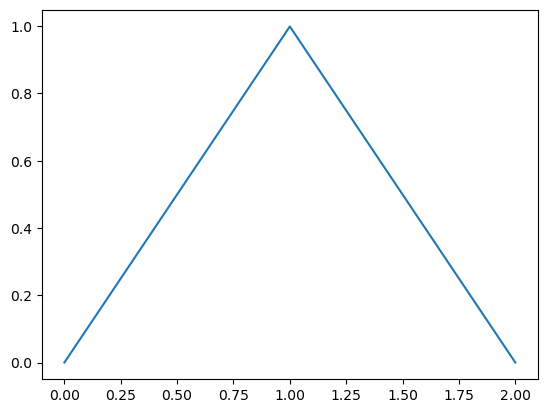

In [39]:
#%matplotlib notebook

fig,ax = plt.subplots(1)

ax.plot(kernel)

plt.show()

# convolve spectrum with kernel

In [40]:
convspec = convolve(specvals, kernel)

# plot

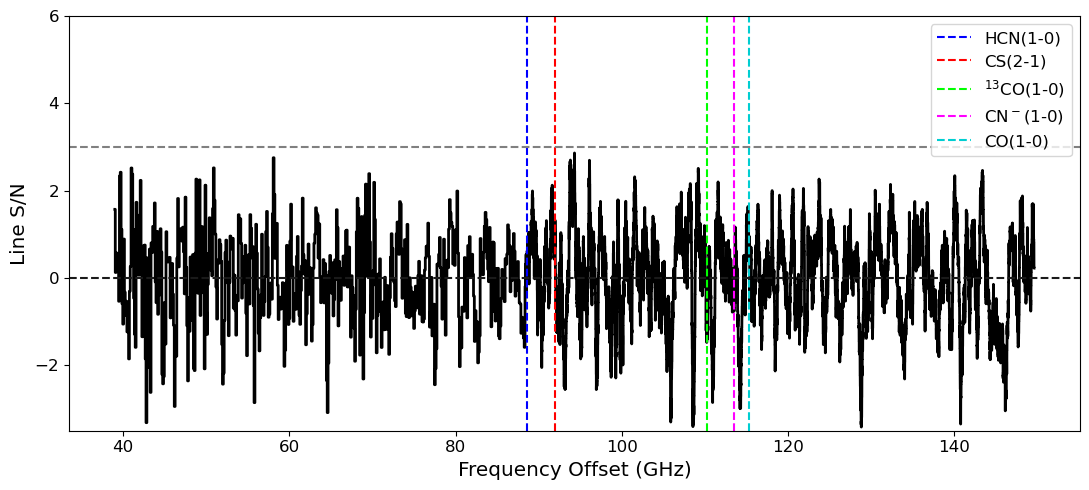

In [50]:
#%matplotlib notebook

fig,ax = plt.subplots(1, figsize=(11,5), tight_layout=True)

#ax.step(freqvals, specvals, where='mid', c='indigo', label='Raw Spectrum')
ax.step(freqvals, convspec, where='mid', c='k', lw=2) # label='Convolved w Kernel'
plt.axvline(x=88.63, color='blue', linestyle='--', label='HCN(1-0)')
plt.axvline(x=91.98, color='red', linestyle='--', label='CS(2-1)')
plt.axvline(x=110.2, color='lime', linestyle='--', label=r'$^{13}$CO(1-0)')
plt.axvline(x=113.49, color='magenta', linestyle='--', label=r'CN$^-$(1-0)')
plt.axvline(x=115.27, color='darkturquoise', linestyle='--', label='CO(1-0)')
plt.legend()

ax.legend(fontsize='large')

ax.set_xlabel('Frequency Offset (GHz)', fontsize='x-large')
ax.set_ylabel(r"Line S/N", fontsize='x-large')
#ax.set_xlim(110,115)
ax.set_ylim(-3.5,6)
ax.axhline(3, color='0.5', ls='--')
ax.axhline(0, color='0.1', ls='--')

ax.tick_params(labelsize='large')
plt.savefig('snratioratio.png')
plt.show()